In [1]:
import numpy as np
import pandas as pd
from numba import njit
from datetime import timedelta
import talib
import vectorbt as vbt
from vectorbt.indicators.factory import IndicatorFactory

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

#My other files
from Data_Handling import *
from Alpaca_Credentials import ALPACA_API_KEY, ALPACA_SECRET_KEY
client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)


import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
from itertools import product
import optuna
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress, pearsonr


In [2]:
# Configuration
symbol = "AAPL"
start_date = "2023-01-01"
end_date = "2023-12-31"
timeframe_unit = "Hour"
multiplier = 4


entry_thresholds = np.arange(5,40,5)
exit_thresholds = np.arange (60,95,5)
rsi_periods = np.arange (7, 98, 7)

In [3]:
# 1. Load Data
data = get_data_auto(symbol, start=start_date, end=end_date, timeframe_unit=timeframe_unit, multiplier=multiplier)
# this gives 24h data not just trading hours so we need to take that into account

optimization_window = 90 # 45 days
execution_window = 30 # 15 days

In [4]:
#2. Define Strategy
@njit
def logic(rsi_vals, entry_threshold, exit_threshold):
    signals = np.where(rsi_vals<entry_threshold,1,0)
    return np.where(rsi_vals>exit_threshold,-1,signals)

def run_RSI_strat1(close, entry_threshold, exit_threshold, rsi_period):
    rsi_vals = vbt.IndicatorFactory.from_talib("RSI").run(close, rsi_period).real.to_numpy()
    return logic(rsi_vals, entry_threshold, exit_threshold)

RSI_strat1 = IndicatorFactory(
    class_name="RSI1",
    short_name="rsi1",
    input_names=["close"],
    param_names=["entry_threshold","exit_threshold","rsi_period"],
    output_names=["signals"] 
    ).from_apply_func(
        run_RSI_strat1
        )



In [ ]:
results = []
all_trades = []

dates = data.index.unique()
total_iterations = (len(dates) - optimization_window) // execution_window

for i in range(total_iterations):
    i = optimization_window + (i * execution_window)
    training_start = dates[i - optimization_window]
    training_end = dates[i - 1]
    test_start = dates[i]
    test_end = dates[i + execution_window]

    training_data = data.loc[training_start:training_end]
    test_data = data.loc[test_start:test_end]

    # === 1. Optimize ===
    call_signals = RSI_strat1.run(
        close=training_data["Close"],
        entry_threshold=entry_thresholds,
        exit_threshold=exit_thresholds,
        rsi_period=rsi_periods,
        param_product=True
    )

    pf_test = vbt.Portfolio.from_signals(
        close=training_data["Close"],
        entries=(call_signals.signals == 1.0),
        exits=(call_signals.signals == -1.0),
        size=1,
        sl_stop=0.05,
        tp_stop= 0.1,
        freq="4h"
    )

    best_params, best_value, best_pf = Overfitting_reduction_simpler(
        pf_test, objective_function=None, smoothing_size=5, filter_threshold=0.0)

    # === 2. Apply best params to test data ===
    optimum_signals = RSI_strat1.run(
        close=test_data["Close"],
        entry_threshold=best_params["rsi1_entry_threshold"],
        exit_threshold=best_params["rsi1_exit_threshold"],
        rsi_period=best_params["rsi1_rsi_period"]
    )

    pf_results = vbt.Portfolio.from_signals(
        close=test_data["Close"],
        entries=(optimum_signals.signals == 1.0),
        exits=(optimum_signals.signals == -1.0),
        size=1,
        sl_stop=0.05,
        tp_stop= 0.1,
        freq="4h"
    )

    #4 Record all trades
    trades_df = pf_results.trades.records[['entry_idx', 'exit_idx']].copy()

    offset = data.index.get_loc(test_data.index[0])
    trades_df['entry_idx'] += offset
    trades_df['exit_idx'] += offset
    all_trades.append(trades_df)

    #5 Record all pfs and deciision metrics
    all_pf.append({
        "Portfolios": pf_results,
        "Expected Returns": best_value,
        "params": best_params,
        "date": test_start
        })

    #print(f"Window starting {test_start}: Return = {pf_results.total_return():.4f}")


In [ ]:
all_trades_df = pd.concat(all_trades, ignore_index=True)
entries, exits = build_signals_from_trade_indices(all_trades_df, data.index)


final_pf = vbt.Portfolio.from_signals(
    close=data["Close"],
    entries=entries,
    exits=exits,
    size=1,
    sl_trail=0.01,
    freq="4h"
)

final_pf.plot()



FigureWidget({
    'data': [{'legendgroup': '0',
              'line': {'color': '#1f77b4'},
              'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': '6d9c4f48-daec-47df-98cf-ca976bd33863',
              'x': array([datetime.datetime(2023, 1, 3, 8, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 12, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 16, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 16, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 29, 20, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 30, 0, 0, tzinfo=TzInfo(UTC))], dtype=object),
              'xaxis': 'x',
              'y': array([130.38  , 125.595 , 124.6283, ..., 192.47  , 192.1894, 192.1501]),
              'yaxis': 'y'},
             {'customdata': array([[ 0.        ,  0.65889218,  0.    

In [7]:
# Build signals
all_trades_df = pd.concat(all_trades, ignore_index=True)
entries, exits = build_signals_from_trade_indices(all_trades_df, data.index)

# Slice by date using .loc to preserve correct datetime index
trading_period_data = data["Close"].iloc[optimization_window:]
trading_period_entries = entries.iloc[optimization_window:]
trading_period_exits = exits.iloc[optimization_window:]

# Create final portfolio
final_pf = vbt.Portfolio.from_signals(
    close=trading_period_data,
    entries=trading_period_entries,
    exits=trading_period_exits,
    size=1,
    sl_trail=0.01,
    freq="4h"
)

# Plot with correct hover labels
final_pf.plot()


FigureWidget({
    'data': [{'legendgroup': '0',
              'line': {'color': '#1f77b4'},
              'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': '320cb758-dde3-49ee-b5e8-2728bfb96456',
              'x': array([datetime.datetime(2023, 1, 31, 0, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 31, 8, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 31, 12, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 16, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 29, 20, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 30, 0, 0, tzinfo=TzInfo(UTC))], dtype=object),
              'xaxis': 'x',
              'y': array([143.    , 141.93  , 143.16  , ..., 192.47  , 192.1894, 192.1501]),
              'yaxis': 'y'},
             {'customdata': array([[ 0.        ,  0.65889218,  0.  

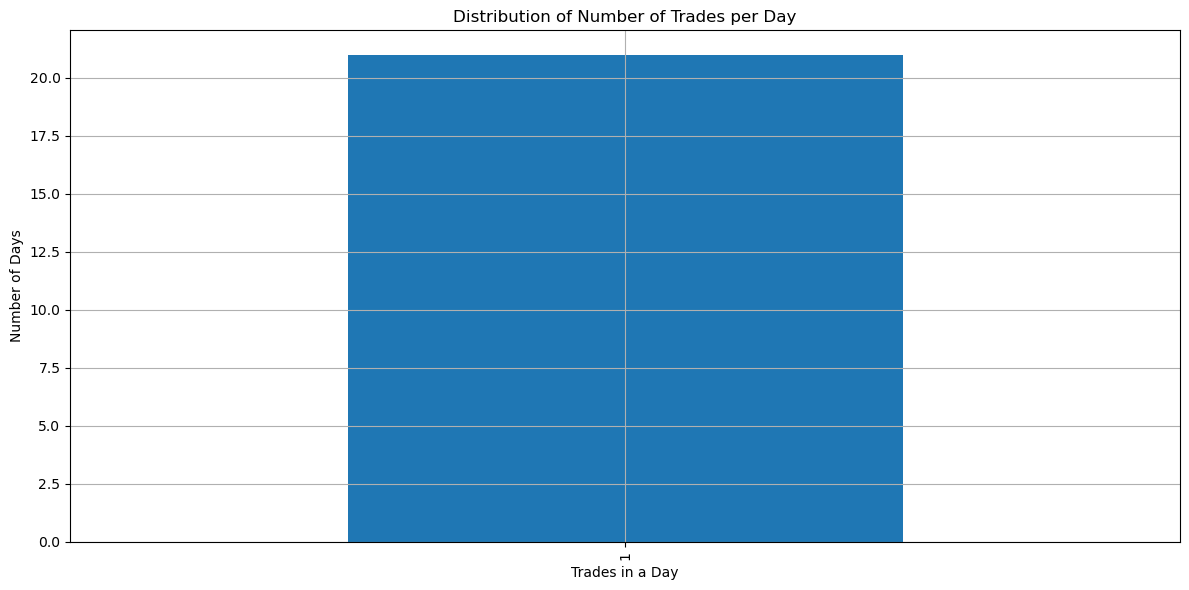

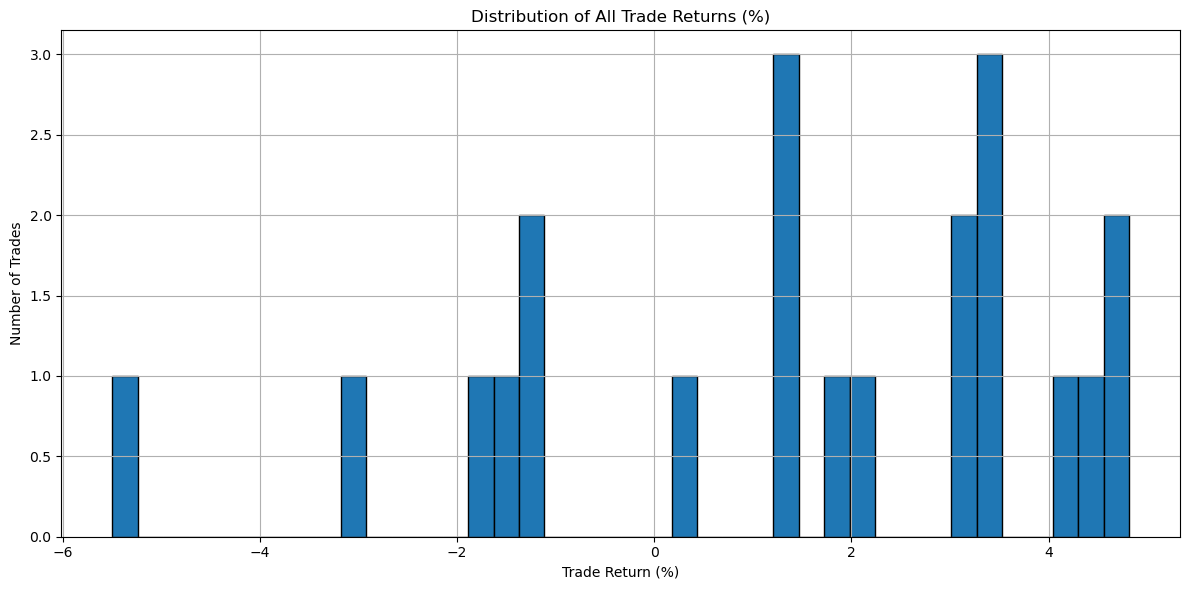

NameError: name 'all_pf' is not defined

In [ ]:

plot_trade_frequency_distribution_per_day(all_trades, data)
plot_trade_return_distribution_from_pf(final_pf)
plot_portfolios_return_distribution(all_pf)